In [325]:
import tensorflow
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [326]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [327]:
X_train = X_train/255
X_test = X_test/255
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [328]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

In [329]:
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation="relu"))
model.add(Dense(32,activation="relu"))
model.add(Dense(10,activation="softmax"))

d:\jup\codespaces-jupyter\.venv313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [330]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [331]:
history = model.fit(X_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9170 - loss: 0.2827 - val_accuracy: 0.9579 - val_loss: 0.1450
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9637 - loss: 0.1203 - val_accuracy: 0.9607 - val_loss: 0.1330
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9744 - loss: 0.0843 - val_accuracy: 0.9683 - val_loss: 0.1076
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9806 - loss: 0.0610 - val_accuracy: 0.9728 - val_loss: 0.0981
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9839 - loss: 0.0509 - val_accuracy: 0.9712 - val_loss: 0.0999
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9875 - loss: 0.0381 - val_accuracy: 0.9704 - val_loss: 0.1112
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9886 - loss: 0.0335 - val_accuracy: 0.9739 - val_loss: 0.1031
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9914 - loss: 0.0264 - 

In [332]:
from sklearn.metrics import accuracy_score

In [333]:
y_prob = model.predict(X_test)
y_pred = y_prob.argmax(axis=1)
accuracy_score(y_test,y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 714us/step


0.9777

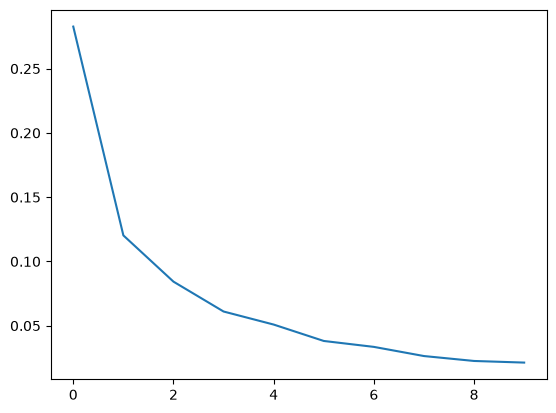

In [334]:
plt.plot(history.history['loss'])


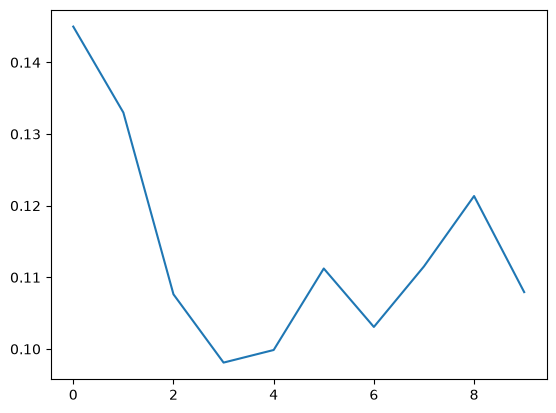

In [335]:
plt.plot(history.history['val_loss'])

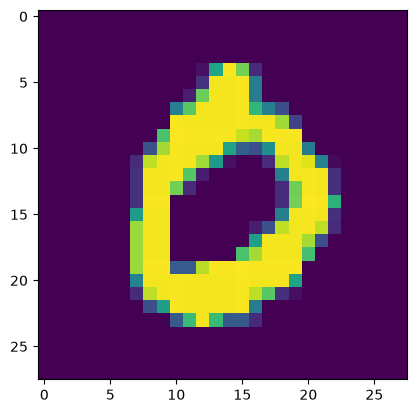

In [336]:
plt.imshow(X_test[3])

In [337]:
model.predict(X_test[3].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


array([0])

In [338]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

img1 = Image.open("img8.png").convert("L")
img1 = ImageOps.invert(img1)
img1 = img1.resize((28, 28))

img1 = np.array(img1) / 255.0

print(img1.shape)

(28, 28)


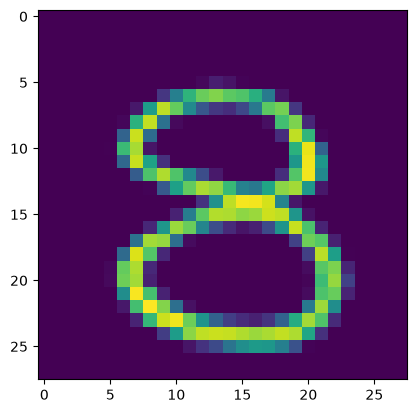

In [339]:
plt.imshow(img1)

In [340]:
pred = model.predict(img1.reshape(1,28,28)).argmax(axis=1)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
[8]


In [ ]:

import cv2
import numpy as np

# Open webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # Flip camera so it behaves like a mirror
    frame = cv2.flip(frame, 1)

    # Create grayscale image
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Threshold to find white handwritten digit
    _, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY_INV)

    # Find contours
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Look for the largest object
    if contours:
        contour = max(contours, key=cv2.contourArea)

        x, y, w, h = cv2.boundingRect(contour)

        # Ignore very small objects
        if w > 30 and h > 30:

            # Draw rectangle around digit
            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

            # Crop digit
            digit = gray[y:y+h, x:x+w]

            # Resize to 28x28
            digit = cv2.resize(digit, (28, 28))

            # Normalize
            digit = digit.astype("float32") / 255.0

            # Add batch dimension
            digit = np.expand_dims(digit, axis=0)

            # Predict
            prediction = model.predict(digit, verbose=0)

            predicted_digit = prediction.argmax(axis=1)[0]

            confidence = np.max(prediction) * 100

            # Display prediction
            cv2.putText(
                frame,
                f"Digit: {predicted_digit} ({confidence:.1f}%)",
                (20, 50),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (0, 255, 0),
                2
            )

    # Show camera
    cv2.imshow("MNIST Digit Recognition", frame)

    # Press q to quit
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
